<a href="https://colab.research.google.com/github/jrdndj/ImproVisAR-PilotPlots/blob/main/ImprovisAR_UEQ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<ipython-input-2-ad72cdeefec7>:40: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  bar_plot = sns.barplot(


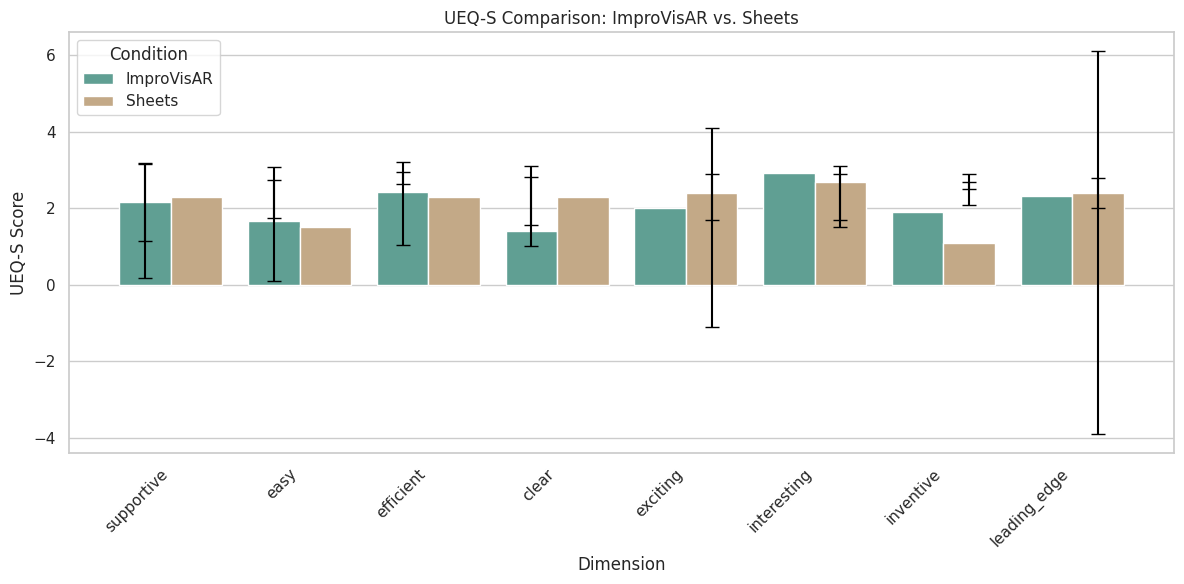

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Manually define the dataset
data = {
    'dimension': [
        'supportive', 'easy', 'efficient', 'clear',
        'exciting', 'interesting', 'inventive', 'leading_edge'
    ],
    'ImproVisAR_mean': [2.167, 1.667, 2.417, 1.417, 2.0, 2.917, 1.917, 2.333],
    'ImproVisAR_std': [1.03, 1.497, 0.669, 1.311, 0.953, 0.289, 0.9, 0.778],
    'Sheets_mean': [2.3, 1.5, 2.3, 2.3, 2.4, 2.7, 1.1, 2.4],
    'Sheets_stdev': [0.6, 2.6, 0.6, 0.8, 0.3, 0.2, 5, 0.4]
}

df = pd.DataFrame(data)

# Melt the data for seaborn barplot format
df_melted = pd.melt(df, id_vars=['dimension'],
                    value_vars=['ImproVisAR_mean', 'Sheets_mean'],
                    var_name='Condition', value_name='Mean')

# Add standard deviation to the melted dataframe
df_melted['Std'] = df_melted.apply(
    lambda row: df['ImproVisAR_std'][df['dimension'] == row['dimension']].values[0] if row['Condition'] == 'ImproVisAR_mean'
    else df['Sheets_stdev'][df['dimension'] == row['dimension']].values[0], axis=1)

# Clean up condition labels
df_melted['Condition'] = df_melted['Condition'].map({
    'ImproVisAR_mean': 'ImproVisAR',
    'Sheets_mean': 'Sheets'
})

# Set plotting style
sns.set(style="whitegrid")

# Plot using seaborn barplot
plt.figure(figsize=(12, 6))
bar_plot = sns.barplot(
    data=df_melted,
    x='dimension',
    y='Mean',
    hue='Condition',
    ci=None,
    capsize=0.1,
    palette={"ImproVisAR": "#5A9", "Sheets": "#CDAA7D"}
)

# Add error bars manually
for i, row in df_melted.iterrows():
    x_pos = i // 2 + (0.2 if row['Condition'] == 'Sheets' else -0.2)
    plt.errorbar(x=x_pos, y=row['Mean'], yerr=row['Std'], fmt='none', c='black', capsize=5)

# Add labels and formatting
plt.ylabel('UEQ-S Score')
plt.xlabel('Dimension')
plt.title('UEQ-S Comparison: ImproVisAR vs. Sheets')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Condition')

# Layout and save
plt.tight_layout()
plt.savefig("ueq_bar_chart.pdf", format="pdf", bbox_inches="tight")
plt.show()
